For every card in the training set to have the following attributes:

Card specific attributes:
- Pokemon popularity index
- Card specific pull rate
- Card current value
- Current card ebay index*1
- Is card a promo
- Is card a chase in its set
- Is pokemon

Set specific attributes:
- Set popularity*2

1: Calculated from the 2026 ebay listings sold, ebay current valid listings, price std from the valid listings and median listing age

2: Calculated with the chase cards ratio out of the set, hit ratio out of the set, set current value with respect to recency and youtube popularity index*3

3: Calculated with the ratio of youtube views, comments, likes, and shares for videos related to the set compared to other sets with respect to recency and sentiment values of every video (positive, negative, neutral)

Need a model that encapsulates all this data + the card price evolution for the last year where every entry is the median price of the card for that month. Some cards have not been out for more than a couple months, so their price evolution will have fewer data points. The model should be able to handle missing data and provide predictions for future card values based on the historical price trends and the attributes listed above while giving a distribution of possible future values rather than a single point estimate.

In [332]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

In [333]:
DATA_DIR = Path("data/processed")

ebayData = json.load(open(DATA_DIR / 'ebay-card-features.json'))
pokemonSetsData = json.load(open(DATA_DIR / 'pokemon-sets.json'))
pokemonPopularityData = json.load(open(DATA_DIR / 'pokemon-popularity.json'))
# redditData = json.load(open(DATA_DIR / 'reddit-index.json'))
youtubeData = json.load(open(DATA_DIR / 'youtube-index.json'))

In [334]:
def find_card_in_sets(set_name, card_number):
    if set_name in pokemonSetsData:
        # print(f"Searching for card {card_number} in set {set_name}")
        set_cards_data = pokemonSetsData[set_name]["hitsRarities"]

        for rarity in set_cards_data:
            cards = rarity["concernedCards"]

            for card in cards:
                if card["number"] == card_number:
                    return card, rarity
    return None

def percentile_normalize(values):
    values = np.asarray(values, dtype=float)

    if len(values) <= 1:
        return np.ones_like(values)

    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(values))

    return ranks / (len(values) - 1)

In [335]:
def calculate_ebay_index(
    ebayData,
    age_lambda=0.03,
    weights=(0.40, 0.20, 0.25, 0.15)
):
    cards = []

    for set_name in ebayData:
        for card_num in ebayData[set_name]:
            card_ebay = ebayData[set_name][card_num]

            sold_volume = card_ebay.get("ebaySoldVolumeFrom2026", 0)

            card_set, _ = find_card_in_sets(set_name, card_num)

            if card_set:
                sold_volume = card_set.get(
                    "ebaySoldVolumeFrom2026",
                    sold_volume
                )

            current_listings = card_ebay.get("listingCount", 0)
            median_price = card_ebay.get("medianPrice", 0)
            price_std = card_ebay.get("priceStdDev", 0)
            median_age = card_ebay.get("medianListingAgeDays", 0)

            sold_volume = max(float(sold_volume or 0), 0)
            current_listings = max(float(current_listings or 0), 0)
            median_price = max(float(median_price or 0), 0)
            price_std = max(float(price_std or 0), 0)
            median_age = max(float(median_age or 0), 0)

            demand = np.log1p(sold_volume)

            liquidity = np.log1p(current_listings)

            age_score = np.exp(-age_lambda * median_age)

            if median_price > 0:
                cv = price_std / median_price
                stability = 1 / (1 + cv)
            else:
                stability = 0

            cards.append({
                "set": set_name,
                "card": card_num,
                "demand": demand,
                "liquidity": liquidity,
                "age": age_score,
                "stability": stability
            })

    demand_norm = percentile_normalize(
        [x["demand"] for x in cards]
    )

    liquidity_norm = percentile_normalize(
        [x["liquidity"] for x in cards]
    )

    age_norm = percentile_normalize(
        [x["age"] for x in cards]
    )

    stability_norm = percentile_normalize(
        [x["stability"] for x in cards]
    )

    card_indices = {}

    for i, card in enumerate(cards):

        index = (
            weights[0] * demand_norm[i] +
            weights[1] * liquidity_norm[i] +
            weights[2] * age_norm[i] +
            weights[3] * stability_norm[i]
        )

        set_name = card["set"]
        card_num = card["card"]

        if set_name not in card_indices:
            card_indices[set_name] = {}

        card_indices[set_name][card_num] = float(
            np.clip(index, 0, 1)
        )

    return card_indices

ebay_indices = calculate_ebay_index(ebayData)

In [336]:
from datetime import datetime
from scipy.optimize import minimize

def calculate_set_popularity_index(
    pokemonSetsData,
    youtubeData,
    calibration_examples=None,
    initial_weights=(0.35, 0.05, 0.30, 0.30),
    video_age_lambda=0.03,
    value_age_lambda = 0.015
):
    def percentile_normalize(values):
        values = np.asarray(values, dtype=float)

        if len(values) <= 1:
            return np.ones_like(values)

        order = np.argsort(values)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(values))

        return ranks / (len(values) - 1)

    youtube_raw = {}

    for set_name, data in youtubeData.items():

        videos = data.get("videos", [])

        total_attention = 0
        weighted_sentiment = 0
        sentiment_weight = 0

        for video in videos:

            views = max(
                float(video.get("view_count", 0) or 0),
                0
            )

            comments = max(
                float(video.get("comment_count", 0) or 0),
                0
            )

            likes = max(
                float(video.get("like_count", 0) or 0),
                0
            )

            publish_time = video.get("publish_time")

            if publish_time:
                try:
                    publish_date = datetime.fromisoformat(
                        publish_time.replace("Z", "+00:00")
                    )

                    now = datetime.now(
                        publish_date.tzinfo
                    )

                    age_days = max(
                        (now - publish_date).days,
                        0
                    )

                except Exception:
                    age_days = 0
            else:
                age_days = 0

            age_months = age_days / 30

            recency = np.exp(
                -video_age_lambda * age_months
            )

            engagement = (
                0.50 * np.log1p(views) +
                0.25 * np.log1p(comments) +
                0.25 * np.log1p(likes)
            )

            weighted_engagement = (
                engagement * recency
            )

            total_attention += weighted_engagement

            sentiment = (
                float(video.get("positive", 0) or 0)
                -
                float(video.get("negative", 0) or 0)
            )

            weighted_sentiment += (
                sentiment * weighted_engagement
            )

            sentiment_weight += weighted_engagement

        if sentiment_weight > 0:
            sentiment_score = (
                weighted_sentiment /
                sentiment_weight
            )
        else:
            sentiment_score = 0

        sentiment_score = (
            sentiment_score + 1
        ) / 2

        youtube_raw[set_name] = {
            "attention": total_attention,
            "sentiment": sentiment_score
        }

    youtube_attention_norm = percentile_normalize([
        data["attention"]
        for data in youtube_raw.values()
    ])

    youtube_indices = {}

    for i, set_name in enumerate(youtube_raw):

        attention = youtube_attention_norm[i]
        sentiment = youtube_raw[set_name]["sentiment"]

        youtube_index = (
            attention *
            (0.8 + 0.4 * sentiment)
        )

        youtube_indices[set_name] = np.clip(
            youtube_index,
            0,
            1
        )

    sets = []

    for set_name, data in pokemonSetsData.items():
        number_of_cards = data.get("numberOfCards", 0)
        if number_of_cards <= 0:
            continue

        chase_ratio = data.get("chaseRatioOutOfHits", 0)
        hit_ratio = data.get("numberOfHits", 0) / number_of_cards

        booster_price = max(float(data.get("boosterPrice", 0) or 0), 0)

        hit_prices = []
        chase_prices = []
        for rarity in data.get("hitsRarities", []):
            for card in rarity.get("concernedCards", []):
                if "priceEvolution" not in card or not card["priceEvolution"] or len(card["priceEvolution"]) == 0:
                    continue

                hit_prices.append(card["priceEvolution"][-1])

                if card.get("isChase", False):
                    chase_prices.append(card["priceEvolution"][-1])

        avg_card_price = np.mean(hit_prices) if hit_prices else 0
        chase_card_price = np.mean(chase_prices) if chase_prices else 0

        release_date_raw = data.get("releaseDate") 
        if release_date_raw:
            try:
                release_date = datetime.fromisoformat(release_date_raw.replace("Z", "+00:00"))
                now = datetime.now(release_date.tzinfo)
                age_days = max((now - release_date).days, 0)
            except Exception:
                age_days = 0
        else:
            age_days = 0

        age_months = age_days / 30
        set_recency = np.exp(-value_age_lambda * age_months)

        price_score = np.log1p(booster_price) * (0.6 + 0.4 * set_recency)

        expected_pull_value = hit_ratio * (
            chase_ratio * chase_card_price +
            (1 - chase_ratio) * avg_card_price
        )

        roi = expected_pull_value / booster_price if booster_price > 0 else 0

        sets.append({
            "set": set_name,
            "pull_value": expected_pull_value,
            "roi": roi,
            "price": price_score,
            "youtube": youtube_indices.get(set_name, 0)
        })

    pull_value_norm = percentile_normalize([x["pull_value"] for x in sets])
    roi_norm = percentile_normalize([x["roi"] for x in sets])
    price_norm = percentile_normalize([x["price"] for x in sets])
    youtube_norm = percentile_normalize([x["youtube"] for x in sets])

    features = {}
    for i, data in enumerate(sets):
        set_name = data["set"]
        features[set_name] = {
            "pull_value": pull_value_norm[i],
            "roi": roi_norm[i],                
            "price": price_norm[i],            
            "youtube": youtube_norm[i]
        }
    weights = np.asarray(initial_weights, dtype=float)

    FEATURE_KEYS = ["pull_value", "roi", "price", "youtube"]

    def to_vector(set_name):
        return np.array([features[set_name][k] for k in FEATURE_KEYS])

    # initial weights — adjust these starting values as you like, they just
    # need to be in the same order as FEATURE_KEYS and sum to 1
    weights = np.array([0.30, 0.25, 0.25, 0.20])

    if calibration_examples is not None:
        high_sets = calibration_examples.get("high", [])
        medium_sets = calibration_examples.get("medium", [])
        low_sets = calibration_examples.get("low", [])

        calibration_sets = high_sets + medium_sets + low_sets

        missing_sets = [s for s in calibration_sets if s not in features]
        if missing_sets:
            raise ValueError(f"Calibration sets not found: {missing_sets}")

        def score(weights, set_name):
            return np.dot(weights, to_vector(set_name))

        def objective(weights):
            loss = 0

            for set_name in high_sets:
                s = score(weights, set_name)
                loss += max(0.8 - s, 0) ** 2

            for set_name in medium_sets:
                s = score(weights, set_name)
                loss += (s - 0.65) ** 2
                if s < 0.5:
                    loss += (0.5 - s) ** 2
                if s >= 0.8:
                    loss += (s - 0.8) ** 2

            for set_name in low_sets:
                s = score(weights, set_name)
                loss += max(s - 0.5, 0) ** 2

            return loss

        constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
        bounds = [(0, 1)] * len(FEATURE_KEYS)

        result = minimize(
            objective,
            weights,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            weights = result.x
        else:
            print("Warning: weight optimization failed:", result.message)

    popularity_indices = {}

    for set_name in features:
        index = np.dot(weights, to_vector(set_name))
        popularity_indices[set_name] = round(float(np.clip(index, 0, 1)), 3)

    return popularity_indices, weights

calibration_examples = {
    "high": [
        "Evolving Skies",
        "151",
        "Ascended Heroes"
    ],

    "medium": [
        "Silver Tempest",
        "Shrouded Fable",
        "Phantasmal Flames",
    ],

    "low": [
        "Sword & Shield",
        "Scarlet & Violet",
        "Perfect Order",
    ]
}

pokemon_set_popularity_indices, weights = calculate_set_popularity_index(pokemonSetsData, youtubeData, calibration_examples=calibration_examples)
sorted_pokemon_set_popularity_indices = dict(sorted(pokemon_set_popularity_indices.items(), key=lambda item: item[1], reverse=True))
sorted_pokemon_set_popularity_indices

{'Evolving Skies': 0.985,
 'Fusion Strike': 0.832,
 'Paldean Fates': 0.813,
 '151': 0.811,
 'Prismatic Evolutions': 0.792,
 'Black Bolt': 0.785,
 'Ascended Heroes': 0.741,
 'White Flare': 0.719,
 'Lost Origin': 0.709,
 'Paldea Evolved': 0.66,
 'Phantasmal Flames': 0.649,
 'Chilling Reign': 0.623,
 'Shrouded Fable': 0.614,
 'Crown Zenith': 0.567,
 'Silver Tempest': 0.557,
 'Mega Evolution': 0.483,
 'Brilliant Stars': 0.469,
 'Destined Rivals': 0.45,
 "Champion's Path": 0.438,
 'Shining Fates': 0.418,
 'Temporal Forces': 0.416,
 'Pitch Black': 0.414,
 'Twilight Masquerade': 0.41,
 'Astral Radiance': 0.4,
 'Scarlet & Violet': 0.378,
 'Obsidian Flames': 0.37,
 'Battle Styles': 0.35,
 'Stellar Crown': 0.332,
 'Chaos Rising': 0.313,
 'Vivid Voltage': 0.306,
 'Surging Sparks': 0.275,
 'Rebel Clash': 0.274,
 'Perfect Order': 0.269,
 'Sword & Shield': 0.254,
 'Darkness Ablaze': 0.223,
 'Paradox Rift': 0.209,
 'Journey Together': 0.191}

INCLUDE THE PROMOS TOO, THE API SCRAPPING SKIPPED ALL PROMO SETS 

In [337]:
def calculate_pokemon_tcg_popularity_index(pokemonPopularity, weights=[0.75, 0.25]):
    def calculate_pokemon_representation(ebayData, pokemonPopularity):
        representation = {
            pokemon.lower(): 0 for pokemon in pokemonPopularity
        }

        for set in ebayData:
            for cardNum in ebayData[set]:
                card, rarity = find_card_in_sets(set, cardNum)

                if card["isPokemon"] == False:
                    continue
                
                cardName = card["name"].lower().split(" ")
                cardPullRate = rarity["pullRate"]

                j = 0
                found = False
                while j < len(cardName):
                    for i in range(j + 1):
                        name = " ".join(cardName[i:j+1])
                        if name in representation:
                            value = 1 / cardPullRate
                            representation[name] += value
                            found = True
                            break
                    if found:
                        break
                    j += 1

        return representation
    
    pokemon_representation = calculate_pokemon_representation(
        ebayData, pokemonPopularity
    )

    min_representation = min(pokemon_representation.values())
    max_representation = max(pokemon_representation.values())

    if max_representation != min_representation:
        pokemon_representation = {
            pokemon: (score - min_representation) / 
                    (max_representation - min_representation)
            for pokemon, score in pokemon_representation.items()
        }
    else:
        pokemon_representation = {
            pokemon: 0 for pokemon in pokemon_representation
        }

    popularity_index = {}

    min_popularity = min(pokemonPopularity.values())
    max_popularity = max(pokemonPopularity.values())

    normalized_popularity = {
        pokemon: (score - min_popularity) / (max_popularity - min_popularity)
        if max_popularity != min_popularity else 0
        for pokemon, score in pokemonPopularity.items()
    }

    for pokemon in normalized_popularity:
        popularity_score = normalized_popularity[pokemon]
        representation_score = pokemon_representation[pokemon.lower()]

        popularity_index[pokemon.lower()] = (
            weights[0] * popularity_score +
            weights[1] * representation_score
        )

    return popularity_index

pokemon_tcg_popularity_indices = calculate_pokemon_tcg_popularity_index(pokemonPopularityData)
sorted_pokemon_tcg_popularity_indices = dict(sorted(pokemon_tcg_popularity_indices.items(), key=lambda item: item[1], reverse=True))

In [338]:
model_data = []

for entry in pokemonSetsData:
    set_name = entry
    set_popularity_index = pokemon_set_popularity_indices.get(entry, 0)

    for rarity in pokemonSetsData[entry]["hitsRarities"]:
        rarity_name = rarity["rarity"]
        specific_pull_rate = rarity["specificCardPullRate"]
        for card_data in rarity["concernedCards"]:
            card_name = card_data["name"]
            card_num = card_data["number"]
            card_is_pokemon = card_data["isPokemon"]
            card_is_chase = card_data["isChase"]
            card_price_on_release = card_data.get("priceOnRelease", 0)
            card_current_price = card_data.get("priceEvolution", [])[-1] if card_data.get("priceEvolution") else 0

            card_popularity_index = 0
            split_card_name = card_name.lower().split(" ")

            j = 0
            found = False
            while j < len(split_card_name):
                for i in range(j + 1):
                    name = " ".join(split_card_name[i:j+1])
                    if name in pokemon_tcg_popularity_indices:
                        card_popularity_index = pokemon_tcg_popularity_indices[name]
                        found = True
                        break
                if found:
                    break
                j += 1

            

            card_ebay_index = ebay_indices.get(set_name, {}).get(card_num, 0)
            
            model_data.append({
                "set": set_name,
                "rarity": rarity_name,
                "pull_rate": specific_pull_rate,
                "card": card_name,
                "number": card_num,
                "is_pokemon": card_is_pokemon,
                "is_chase": card_is_chase,
                "price_on_release": card_price_on_release,
                "current_price": card_current_price,
                "popularity_index": card_popularity_index,
                "ebay_index": card_ebay_index,
                "set_popularity_index": set_popularity_index
            })


model_df = pd.DataFrame(model_data)
model_df.head()

,set,rarity,pull_rate,card,number,is_pokemon,is_chase,price_on_release,current_price,popularity_index,ebay_index,set_popularity_index
0,151,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,1.25,0.645570,0.839349,0.811
1,151,Double Rare,0.010417,Charizard ex,006,True,False,4.14,7.57,0.853420,0.743204,0.811
2,151,Double Rare,0.010417,Blastoise ex,009,True,False,0.86,2.56,0.665279,0.823262,0.811
3,151,Double Rare,0.010417,Arbok ex,024,True,False,0.97,1.48,0.430049,0.585807,0.811
4,151,Double Rare,0.010417,Ninetales ex,038,True,False,1.14,1.91,0.670476,0.652094,0.811


In [339]:
model_df["logReturn"] = np.where(
    (model_df["current_price"] > 0) & (model_df["price_on_release"] > 0),
    np.log(model_df["current_price"] / model_df["price_on_release"]),
    np.nan
)

model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=["logReturn"])
model_df

,set,rarity,pull_rate,card,number,is_pokemon,is_chase,price_on_release,current_price,popularity_index,ebay_index,set_popularity_index,logReturn
0,151,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,1.25,0.645570,0.839349,0.811,0.385662
1,151,Double Rare,0.010417,Charizard ex,006,True,False,4.14,7.57,0.853420,0.743204,0.811,0.603497
2,151,Double Rare,0.010417,Blastoise ex,009,True,False,0.86,2.56,0.665279,0.823262,0.811,1.090830
3,151,Double Rare,0.010417,Arbok ex,024,True,False,0.97,1.48,0.430049,0.585807,0.811,0.422501
4,151,Double Rare,0.010417,Ninetales ex,038,True,False,1.14,1.91,0.670476,0.652094,0.811,0.516075
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2257,Pitch Black,Special Illustration Rare,0.002083,Mega Darkrai ex,116,True,True,375.00,215.36,0.788742,0.802941,0.414,-0.554615
2258,Pitch Black,Special Illustration Rare,0.002083,Morpeko ex,117,True,True,200.00,97.04,0.406617,0.645967,0.414,-0.723194
2259,Pitch Black,Special Illustration Rare,0.002083,Gladion's Final Battle,118,False,True,47.00,33.36,0.000000,0.571680,0.414,-0.342790
2260,Pitch Black,Special Illustration Rare,0.002083,Gwynn,119,False,True,83.60,36.38,0.000000,0.603431,0.414,-0.832024


In [340]:
model_df.describe(include='all')

,set,rarity,pull_rate,card,number,is_pokemon,is_chase,price_on_release,current_price,popularity_index,ebay_index,set_popularity_index,logReturn
count,2136,2136,2136.000000,2136,2136,2136,2136,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000,2136.000000
unique,37,15,NaN,1329,289,2,2,NaN,NaN,NaN,NaN,NaN,NaN
top,Silver Tempest,Ultra Rare,NaN,Charizard ex,173,True,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,106,644,NaN,8,20,1637,1974,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.003923,NaN,NaN,NaN,NaN,23.790417,26.984036,0.365682,0.511880,0.524507,0.092002
std,NaN,NaN,0.003141,NaN,NaN,NaN,NaN,76.111636,99.909630,0.252941,0.173276,0.220669,0.644351
min,NaN,NaN,0.000397,NaN,NaN,NaN,NaN,0.040000,0.030000,0.000000,0.056684,0.191000,-3.036554
25%,NaN,NaN,0.001634,NaN,NaN,NaN,NaN,1.827500,2.020000,0.161516,0.370789,0.350000,-0.065051
50%,NaN,NaN,0.003086,NaN,NaN,NaN,NaN,5.365000,5.460000,0.397588,0.522772,0.469000,0.201828
75%,NaN,NaN,0.005556,NaN,NaN,NaN,NaN,14.700000,16.085000,0.560629,0.651699,0.719000,0.477099


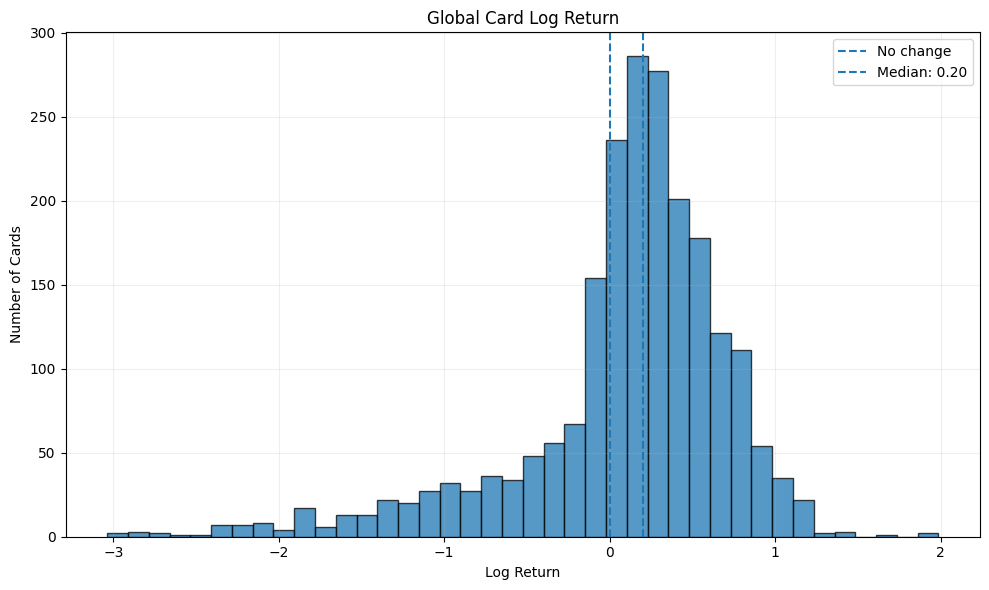

In [341]:
values = model_df["logReturn"]

plt.figure(figsize=(10, 6))

plt.hist(
    values,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="No change"
)

plt.axvline(
    values.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {values.median():.2f}"
)

plt.xlabel("Log Return")
plt.ylabel("Number of Cards")
plt.title("Global Card Log Return")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

162


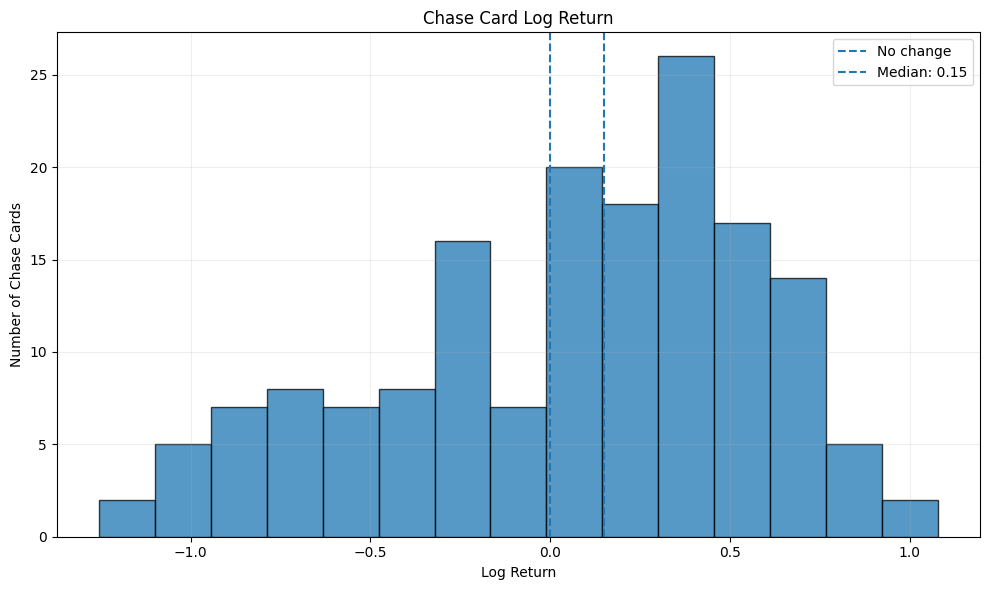

In [342]:
values = model_df.loc[
    model_df["is_chase"] == True,
    "logReturn"
].dropna()

print(values.size)

plt.figure(figsize=(10, 6))

plt.hist(
    values,
    bins=15,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="No change"
)

plt.axvline(
    values.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {values.median():.2f}"
)

plt.xlabel("Log Return")
plt.ylabel("Number of Chase Cards")
plt.title("Chase Card Log Return")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Pokemon cards: 1637, Non-Pokemon cards: 499


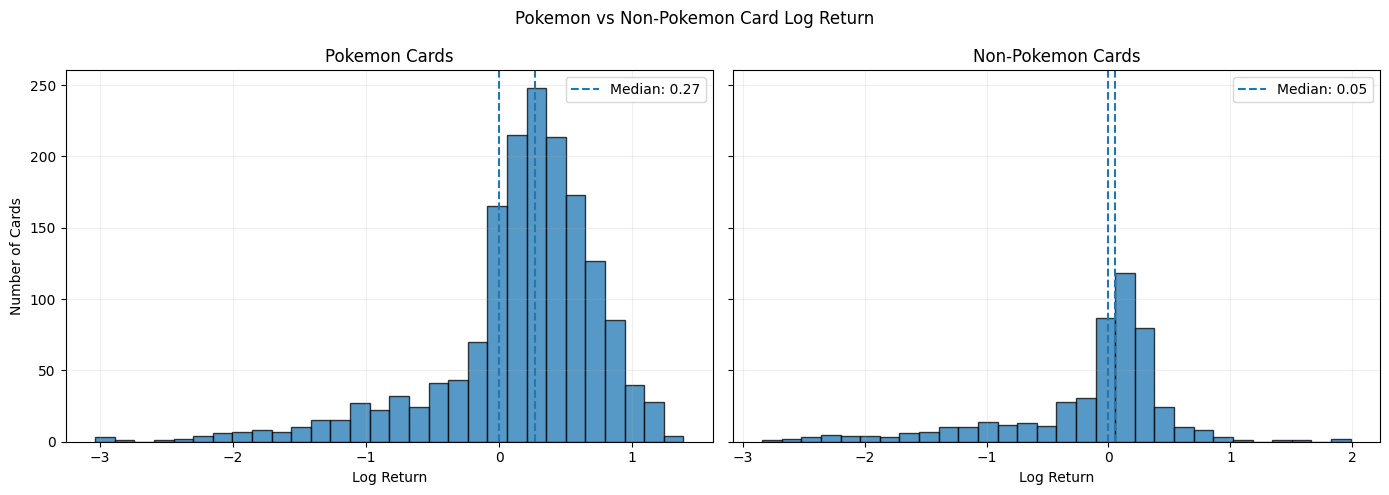

In [343]:
pokemon = model_df.loc[
    model_df["is_pokemon"] == True,
    "logReturn"
]

non_pokemon = model_df.loc[
    model_df["is_pokemon"] == False,
    "logReturn"
]

print(
    f"Pokemon cards: {pokemon.size}, Non-Pokemon cards: {non_pokemon.size}"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)

axes[0].hist(
    pokemon,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

axes[0].axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

axes[0].axvline(
    pokemon.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {pokemon.median():.2f}"
)

axes[0].set_title("Pokemon Cards")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Number of Cards")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].hist(
    non_pokemon,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

axes[1].axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

axes[1].axvline(
    non_pokemon.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {non_pokemon.median():.2f}"
)

axes[1].set_title("Non-Pokemon Cards")
axes[1].set_xlabel("Log Return")
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.suptitle("Pokemon vs Non-Pokemon Card Log Return")

plt.tight_layout()
plt.show()

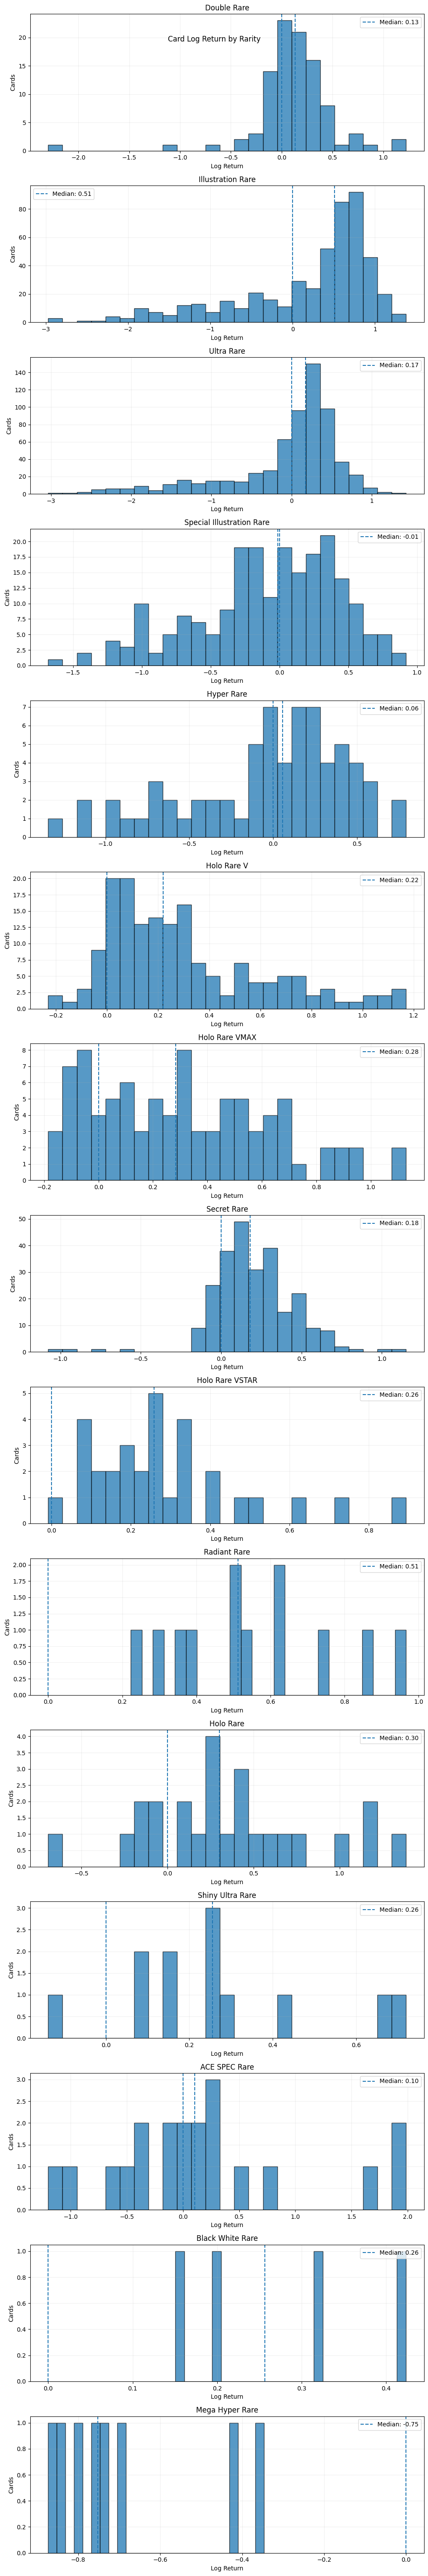

In [344]:
def plot_logreturn_by_rarity(
    df: pd.DataFrame,
    rarity: str = None
):
    if rarity is not None:
        values = df.loc[
            df["rarity"] == rarity,
            "logReturn"
        ].dropna()

        plt.figure(figsize=(10, 6))

        plt.hist(
            values,
            bins=30,
            edgecolor="black",
            alpha=0.75
        )

        plt.axvline(
            0,
            linestyle="--",
            linewidth=1.5
        )

        plt.axvline(
            values.median(),
            linestyle="--",
            linewidth=1.5,
            label=f"Median: {values.median():.2f}"
        )

        plt.xlabel("Log Return")
        plt.ylabel("Number of Cards")
        plt.title(f"Log Return — {rarity}")
        plt.legend()
        plt.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()

        return

rarities = (
    model_df["rarity"]
    .dropna()
    .unique()
)

n = len(rarities)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(10, 4 * n)
)

if n == 1:
    axes = [axes]

for ax, rarity_name in zip(axes, rarities):
    values = model_df.loc[
        model_df["rarity"] == rarity_name,
        "logReturn"
    ].dropna()

    ax.hist(
        values,
        bins=25,
        edgecolor="black",
        alpha=0.75
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    ax.axvline(
        values.median(),
        linestyle="--",
        linewidth=1.5,
        label=f"Median: {values.median():.2f}"
    )

    ax.set_title(str(rarity_name))
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Cards")
    ax.legend()
    ax.grid(alpha=0.2)

fig.suptitle("Card Log Return by Rarity")

plt.tight_layout()
plt.show()

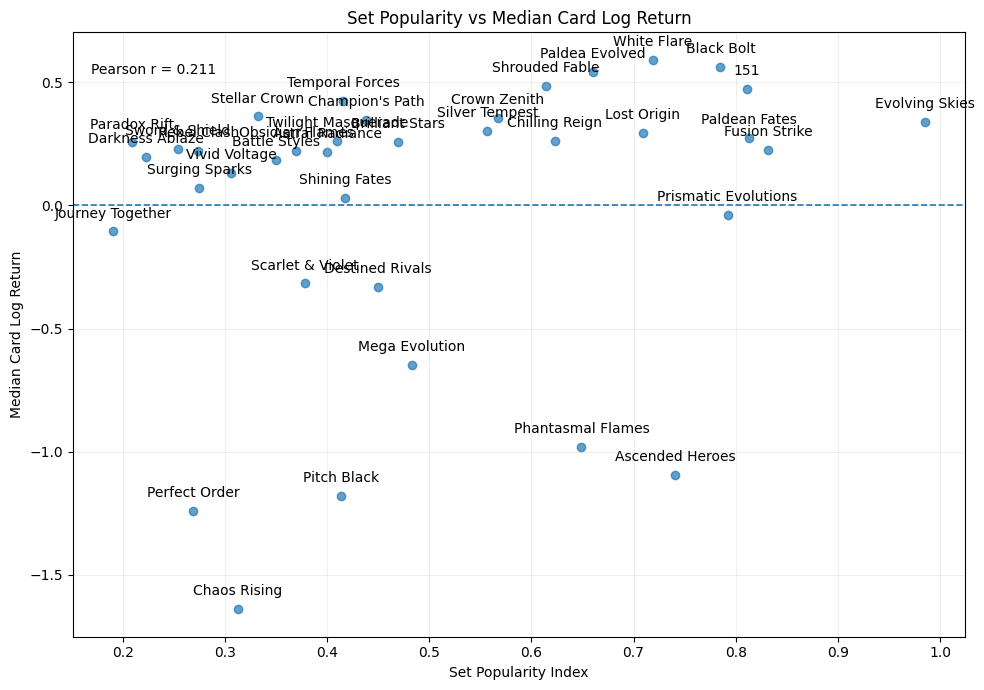

In [345]:
set_df = (
    model_df
    .groupby("set")
    .agg(
        medianLogReturn=("logReturn", "median"),
        setPopularityIndex=("set_popularity_index", "first")
    )
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    set_df["setPopularityIndex"],
    set_df["medianLogReturn"],
    alpha=0.7
)

for row in set_df.itertuples():
    plt.annotate(
        row.set,
        (row.setPopularityIndex, row.medianLogReturn),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

plt.axhline(0, linestyle="--", linewidth=1.2)

plt.xlabel("Set Popularity Index")
plt.ylabel("Median Card Log Return")
plt.title("Set Popularity vs Median Card Log Return")

correlation = set_df[["setPopularityIndex", "medianLogReturn"]].corr().iloc[0, 1]

plt.text(
    0.02, 0.95,
    f"Pearson r = {correlation:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

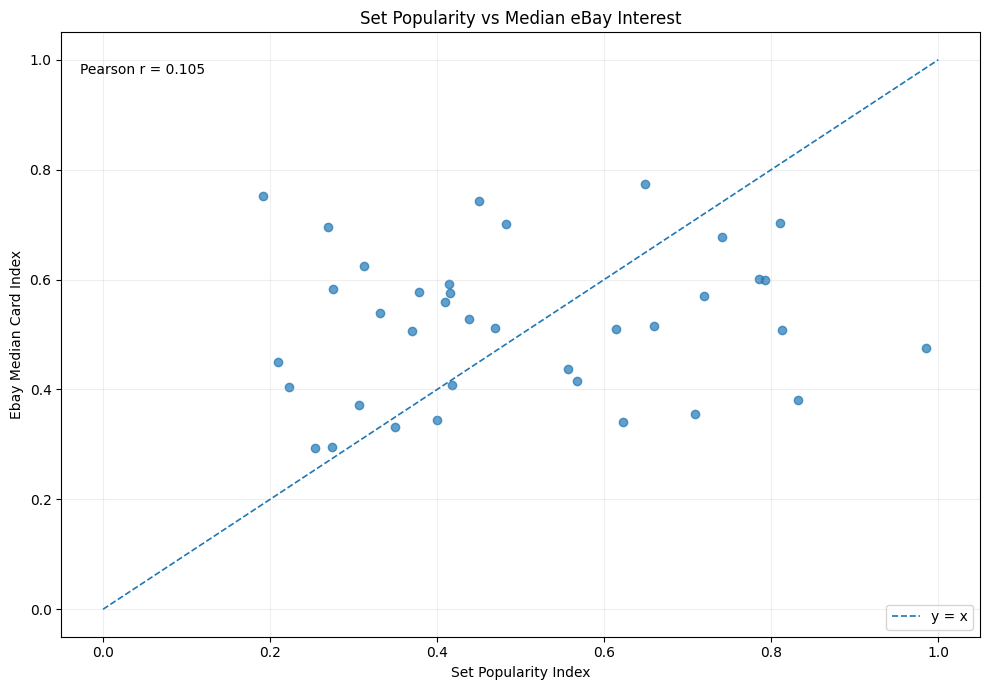

In [346]:
set_df = (
    model_df
    .groupby("set")
    .agg(
        ebayIndex=("ebay_index", "median"),
        setPopularityIndex=("set_popularity_index", "first")
    )
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    set_df["setPopularityIndex"],
    set_df["ebayIndex"],
    alpha=0.7
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="y = x"
)

plt.xlabel("Set Popularity Index")
plt.ylabel("Ebay Median Card Index")
plt.title("Set Popularity vs Median eBay Interest")

correlation = set_df[
    ["ebayIndex", "setPopularityIndex"]
].corr().iloc[0, 1]

plt.text(
    0.02,
    0.95,
    f"Pearson r = {correlation:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

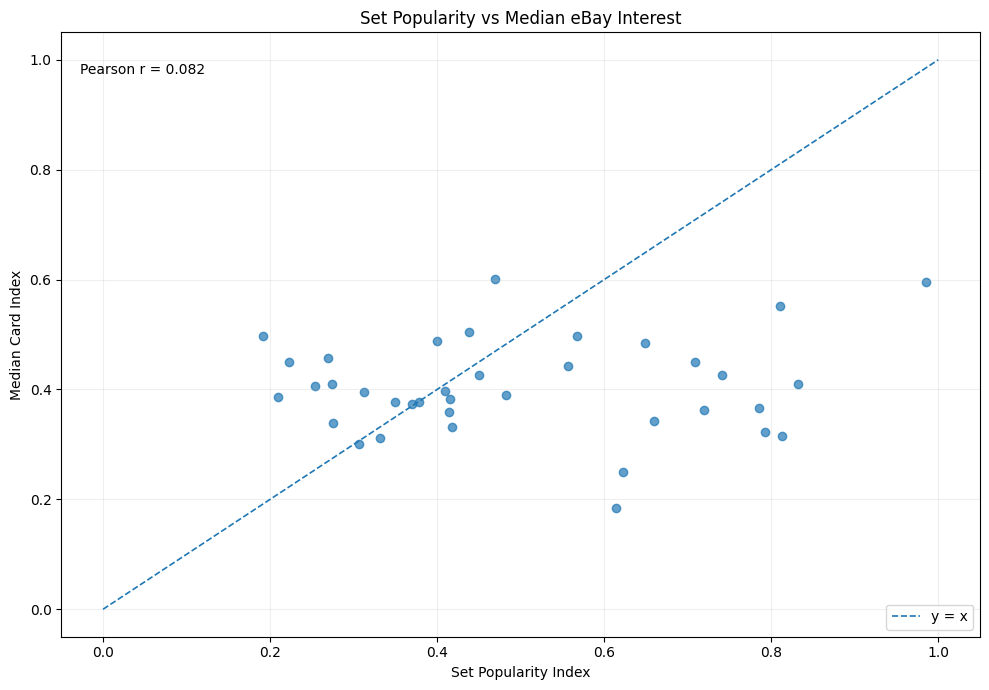

In [347]:
set_df = (
    model_df
    .groupby("set")
    .agg(
        popularityIndex=("popularity_index", "median"),
        setPopularityIndex=("set_popularity_index", "first")
    )
    .dropna()
    .reset_index()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    set_df["setPopularityIndex"],
    set_df["popularityIndex"],
    alpha=0.7
)

# Perfect agreement line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="y = x"
)

plt.xlabel("Set Popularity Index")
plt.ylabel("Median Card Index")
plt.title("Set Popularity vs Median eBay Interest")

correlation = set_df[
    ["setPopularityIndex", "popularityIndex"]
].corr().iloc[0, 1]

plt.text(
    0.02,
    0.95,
    f"Pearson r = {correlation:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [348]:
model_data = []

# Normalize as_of once, outside the loops
as_of = pd.Timestamp.today()

def months_between(earlier: pd.Timestamp, later: pd.Timestamp) -> int:
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)


for set_name, set_data in pokemonSetsData.items():
    set_popularity_index = pokemon_set_popularity_indices.get(set_name, 0)

    # Get the set release date directly
    release_date = set_data.get("releaseDate")
    if pd.notna(release_date):
        release_date = pd.Timestamp(release_date)
        months_since_release = months_between(release_date, as_of)
    else:
        months_since_release = None

    for rarity in set_data.get("hitsRarities", []):
        rarity_name = rarity["rarity"]
        specific_pull_rate = rarity["specificCardPullRate"]

        for card_data in rarity.get("concernedCards", []):
            card_name = card_data["name"]
            card_num = card_data["number"]
            card_is_pokemon = card_data["isPokemon"]
            card_is_chase = card_data["isChase"]
            card_price_on_release = card_data.get("priceOnRelease", 0)

            # Get card popularity
            card_popularity_index = 0
            split_card_name = card_name.lower().split()

            for j in range(len(split_card_name)):
                found = False

                for i in range(j + 1):
                    name = " ".join(split_card_name[i:j + 1])

                    if name in pokemon_tcg_popularity_indices:
                        card_popularity_index = pokemon_tcg_popularity_indices[name]
                        found = True
                        break

                if found:
                    break

            card_ebay_index = (
                ebay_indices
                .get(set_name, {})
                .get(card_num, 0)
            )

            prices = card_data.get("priceEvolution")

            if not isinstance(prices, list) or len(prices) < 2:
                continue

            skip = 0

            if months_since_release is not None:
                if months_since_release < 12:
                    skip = max(0, len(prices) - months_since_release)

            trimmed = prices[skip:]

            if len(trimmed) < 2:
                continue

            for offset, price in enumerate(trimmed):
                t = offset

                model_data.append({
                    "set": set_name,
                    "t": t,
                    "rarity": rarity_name,
                    "pull_rate": specific_pull_rate,
                    "card": card_name,
                    "number": card_num,
                    "is_pokemon": card_is_pokemon,
                    "is_chase": card_is_chase,
                    "price_on_release": card_price_on_release,
                    "current_price": price,
                    "popularity_index": card_popularity_index,
                    "ebay_index": card_ebay_index,
                    "set_popularity_index": set_popularity_index,
                })

model_df = pd.DataFrame(model_data)
model_df

,set,t,rarity,pull_rate,card,number,is_pokemon,is_chase,price_on_release,current_price,popularity_index,ebay_index,set_popularity_index
0,151,0,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,0.85,0.64557,0.839349,0.811
1,151,1,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,0.98,0.64557,0.839349,0.811
2,151,2,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,0.67,0.64557,0.839349,0.811
3,151,3,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,0.74,0.64557,0.839349,0.811
4,151,4,Double Rare,0.010417,Venusaur ex,003,True,False,0.85,0.76,0.64557,0.839349,0.811
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25965,Chaos Rising,1,Special Illustration Rare,0.001667,Roxie's Performance,121,False,False,62.63,22.10,0.00000,0.564996,0.313
25966,Chaos Rising,2,Special Illustration Rare,0.001667,Roxie's Performance,121,False,False,62.63,23.04,0.00000,0.564996,0.313
25967,Chaos Rising,0,Mega Hyper Rare,0.001000,Mega Greninja ex,122,True,True,398.80,266.05,0.78435,0.686921,0.313
25968,Chaos Rising,1,Mega Hyper Rare,0.001000,Mega Greninja ex,122,True,True,398.80,190.49,0.78435,0.686921,0.313


In [349]:
model_df.columns

Index(['set', 't', 'rarity', 'pull_rate', 'card', 'number', 'is_pokemon',
       'is_chase', 'price_on_release', 'current_price', 'popularity_index',
       'ebay_index', 'set_popularity_index'],
      dtype='str')

In [350]:
def prepare_next_month_dataset(model_df: pd.DataFrame):

    df = model_df.copy()

    df = df.sort_values(
        ["set", "card", "t"]
    )

    df["next_price"] = (
        df
        .groupby(["set", "card"])["current_price"]
        .shift(-1)
    )

    valid_prices = (
        (df["current_price"] > 0) &
        (df["next_price"] > 0) &
        np.isfinite(df["current_price"]) &
        np.isfinite(df["next_price"])
    )

    df["next_log_return"] = np.nan

    df.loc[valid_prices, "next_log_return"] = (
        np.log(
            df.loc[valid_prices, "next_price"] /
            df.loc[valid_prices, "current_price"]
        )
    )

    df = df[
        np.isfinite(df["next_log_return"])
    ].copy()

    return df

def add_price_features(df: pd.DataFrame):
    df = df.copy()

    group = df.groupby(["set", "card"])

    # Previous returns
    df["log_return_1m"] = (
        group["current_price"]
        .transform(lambda x: np.log(x / x.shift(1)))
    )

    df["log_return_2m"] = (
        group["current_price"]
        .transform(lambda x: np.log(x / x.shift(2)))
    )

    df["log_return_3m"] = (
        group["current_price"]
        .transform(lambda x: np.log(x / x.shift(3)))
    )

    # Price momentum
    df["momentum_3m"] = (
        group["current_price"]
        .transform(lambda x: x / x.shift(3) - 1)
    )

    # Rolling volatility
    df["volatility_3m"] = (
        group["log_return_1m"]
        .transform(lambda x: x.rolling(3).std())
    )

    # Card age
    df["card_age"] = df["t"]

    return df

In [351]:
df = prepare_next_month_dataset(model_df)
df = add_price_features(df)

df["log_return_1m"] = df["log_return_1m"].fillna(0)
df["log_return_2m"] = df["log_return_2m"].fillna(0)
df["log_return_3m"] = df["log_return_3m"].fillna(0)

df["momentum_3m"] = df["momentum_3m"].fillna(0)

df["volatility_3m"] = (
    df["volatility_3m"]
    .fillna(df["volatility_3m"].median())
)

df["history_length"] = (
    df.groupby(["set", "card"])
      .cumcount()
)

In [352]:
FEATURES = [
    "pull_rate",
    "rarity",
    "is_pokemon",
    "is_chase",
    "popularity_index",
    "ebay_index",
    "set_popularity_index",
    "current_price",
    "log_return_1m",
    "log_return_2m",
    "log_return_3m",
    "momentum_3m",
    "volatility_3m",
    "card_age",
    "history_length"
]

In [353]:
from ngboost import NGBRegressor
from ngboost.distns import T
from sklearn.tree import DecisionTreeRegressor

model = NGBRegressor(
    Dist=T,
    Base=DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=20
    ),
    n_estimators=300,
    learning_rate=0.03,
    verbose=False
)

In [354]:
def time_split(df, test_fraction=0.2):

    times = sorted(df["t"].unique())

    split_idx = int(
        len(times) * (1 - test_fraction)
    )

    train_times = times[:split_idx]
    test_times = times[split_idx:]

    train = df[
        df["t"].isin(train_times)
    ]

    test = df[
        df["t"].isin(test_times)
    ]

    return train, test

In [355]:
train, test = time_split(df)

X_train = train[FEATURES]
y_train = train["next_log_return"]

X_test = test[FEATURES]
y_test = test["next_log_return"]

In [356]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


categorical_features = [
    "rarity"
]

numeric_features = [
    "pull_rate",
    "is_pokemon",
    "is_chase",
    "popularity_index",
    "ebay_index",
    "set_popularity_index",
    "current_price",
    "log_return_1m",
    "log_return_2m",
    "log_return_3m",
    "momentum_3m",
    "volatility_3m",
    "card_age",
    "history_length",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [357]:
print(y_train.isna().sum())
print(np.isnan(y_train).sum())
print(
    y_train[
        ~np.isfinite(y_train)
    ]
)
print(np.isinf(y_train).sum())

print(y_train.dtype)

print(y_train.describe())

0
0
Series([], Name: next_log_return, dtype: float64)
0
float64
count    20163.000000
mean         0.018154
std          1.538015
min         -9.463217
25%         -0.256508
50%          0.032179
75%          0.422737
max          9.587937
Name: next_log_return, dtype: float64


In [358]:
X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_test_encoded = preprocessor.transform(
    X_test
)

In [361]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

model.fit(
    X_train_encoded,
    y_train
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ngboost/distns/t.py:65: RuntimeWarning: overflow encountered in exp
  self.df = np.exp(params[2])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ngboost/distns/t.py:65: RuntimeWarning: overflow encountered in exp
  self.df = np.exp(params[2])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ngboost/distns/t.py:65: RuntimeWarning: overflow encountered in exp
  self.df = np.exp(params[2])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:8023: RuntimeWarning: divide by zero encountered in log
  return (np.log(sc.poch(0.5 * df, 0.5))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:8025: RuntimeWarning: overflow encountered in divide
  - (df + 1)/2*np.log1p(x * x/df))
/Library/Frameworks/Python.framework/Versions/3.12/li

,Dist,<class 'ngboost.distns.t.T'>
,Score,<class 'ngboo...res.LogScore'>
,Base,DecisionTreeR...mples_leaf=20)
,natural_gradient,True
,n_estimators,300
,learning_rate,0.03
,minibatch_frac,1.0
,col_sample,1.0
,verbose,False
,verbose_eval,100
,tol,0.0001


In [363]:
dist = model.pred_dist(
    X_test_encoded
)

samples = dist.rvs(
    size=(10000, len(X_test_encoded))
)

In [365]:
predicted_return = np.median(
    samples,
    axis=0
)

predicted_price = (
    test["current_price"].to_numpy()
    * np.exp(predicted_return)
)

actual_price = (
    test["next_price"].to_numpy()
)

In [366]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    actual_price,
    predicted_price
)

rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        predicted_price
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 24.01935173896971
RMSE: 104.52610748311564


In [367]:
actual = np.asarray(actual_price)
predicted = np.asarray(predicted_price)

mape = np.mean(
    np.abs(
        (actual - predicted) /
        actual
    )
) * 100

print("MAPE:", mape)

MAPE: 671.5874867333326


In [368]:
actual_log = np.log(actual)
predicted_log = np.log(predicted)

log_mae = np.mean(
    np.abs(
        actual_log - predicted_log
    )
)

log_rmse = np.sqrt(
    np.mean(
        (actual_log - predicted_log) ** 2
    )
)

print("Log MAE :", log_mae)
print("Log RMSE:", log_rmse)

Log MAE : 0.84566935267326
Log RMSE: 1.3517037702992454


In [369]:
actual_return = (
    np.log(actual_price) -
    np.log(test["current_price"].to_numpy())
)

predicted_return = np.log(
    predicted_price
) - np.log(
    test["current_price"].to_numpy()
)

direction_accuracy = np.mean(
    np.sign(actual_return) ==
    np.sign(predicted_return)
)

print(
    "Directional accuracy:",
    direction_accuracy
)

Directional accuracy: 0.7290307548928239


In [370]:
future_prices = (
    test["current_price"].to_numpy()[None, :]
    * np.exp(samples)
)

p05 = np.percentile(
    future_prices,
    5,
    axis=0
)

p95 = np.percentile(
    future_prices,
    95,
    axis=0
)

actual = test["next_price"].to_numpy()

coverage_90 = np.mean(
    (actual >= p05) &
    (actual <= p95)
)

print(
    "90% interval coverage:",
    coverage_90
)

/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_6056/1023802864.py:3: RuntimeWarning: overflow encountered in exp
  * np.exp(samples)
/var/folders/63/z6gq_ry925b6ttrn52rwrwp80000gn/T/ipykernel_6056/1023802864.py:2: RuntimeWarning: overflow encountered in multiply
  test["current_price"].to_numpy()[None, :]


90% interval coverage: 0.9496738117427772


In [371]:
p25 = np.percentile(
    future_prices,
    25,
    axis=0
)

p75 = np.percentile(
    future_prices,
    75,
    axis=0
)

coverage_50 = np.mean(
    (actual >= p25) &
    (actual <= p75)
)

print(
    "50% interval coverage:",
    coverage_50
)

50% interval coverage: 0.5943616029822927


In [ ]:
import properscoring as ps

crps = ps.crps_ensemble(
    actual,
    future_prices.T
)

print(
    "Mean CRPS:",
    np.mean(crps)
)

Mean CRPS: nan


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _crps_ensemble_gufunc
  return self.ufunc(*args, **kwargs)


In [ ]:
def predict_next_price(
    model,
    preprocessor,
    card_df,
    n_samples=10000
):
    card_df = card_df.sort_values("t")

    latest = card_df.iloc[-1:].copy()

    latest = add_price_features(latest)

    latest["history_length"] = len(card_df)

    for col in [
        "log_return_1m",
        "log_return_2m",
        "log_return_3m",
        "momentum_3m"
    ]:
        latest[col] = latest[col].fillna(0)

    latest["volatility_3m"] = (
        latest["volatility_3m"]
        .fillna(0)
    )

    X = latest[FEATURES]

    X_encoded = preprocessor.transform(X)

    dist = model.pred_dist(X_encoded)

    returns = dist.rvs(
        size=n_samples
    ).reshape(-1)

    current_price = float(
        latest["current_price"].iloc[0]
    )

    prices = (
        current_price *
        np.exp(returns)
    )

    return {
        "mean": float(np.mean(prices)),
        "median": float(np.median(prices)),
        "p05": float(np.percentile(prices, 5)),
        "p10": float(np.percentile(prices, 10)),
        "p25": float(np.percentile(prices, 25)),
        "p50": float(np.percentile(prices, 50)),
        "p75": float(np.percentile(prices, 75)),
        "p90": float(np.percentile(prices, 90)),
        "p95": float(np.percentile(prices, 95)),
        "samples": prices,
    }